# Notebook 01 — Data Loading & Quality Control

**Dataset:** GSE116256 — van Galen et al., Cell 2019  
**Goal:** Load raw single-cell expression data and filter low-quality cells.

## What is scRNA-seq?

Unlike bulk RNA-seq (which gives the *average* expression across thousands of cells), **single-cell RNA-seq (scRNA-seq)** measures gene expression in **each individual cell**. This allows us to:
- Identify distinct cell populations in a tumor
- Detect rare malignant subclones
- Reconstruct differentiation trajectories

The van Galen 2019 dataset contains **38,410 cells** from 16 AML patients and 5 healthy donors. Each cell has a measurement for ~33,000 genes.

## AnnData format

Scanpy uses the **AnnData** object to store scRNA-seq data:
```
adata
  .X         → expression matrix (cells × genes)
  .obs       → cell metadata (patient, cell type, QC metrics)
  .var       → gene metadata (gene names, HVG flag)
  .obsm      → embeddings (PCA, UMAP)
  .uns       → unstructured data (clustering results, PAGA graph)
```

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.utils import (
    load_all_samples,
    compute_qc_metrics,
    filter_cells_qc,
    plot_qc_violin,
    set_plot_style
)

set_plot_style()
sc.settings.verbosity = 1
sc.logging.print_header()
print(f"Scanpy version: {sc.__version__}")

Scanpy version: 1.11.5


/var/folders/cv/9vy8yk7x1s73_8cbwdkqfldh0000gn/T/ipykernel_20306/3574885768.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


## 1.1 — Load all samples

Each sample is one patient (AML or healthy bone marrow donor).  
We load all `.dem.txt.gz` + `.anno.txt.gz` pairs and concatenate them.

> **Before running:** Make sure you downloaded the data into `../data/raw/`  
> See `../data/README.md` for download instructions.

In [2]:
DATA_DIR = "../data/raw"

adata = load_all_samples(DATA_DIR)
print(f"\nDataset shape: {adata.shape}")
print(f"Columns in .obs: {adata.obs.columns.tolist()}")

  Loaded BM1: 108 cells, 27899 genes
  Loaded BM2: 188 cells, 27899 genes
  Loaded BM5-34p: 1431 cells, 27899 genes
  Loaded BM5-34p38n: 1590 cells, 27899 genes
  Loaded MUTZ3: 1502 cells, 27899 genes
  Loaded OCI-AML3: 1178 cells, 27899 genes

Total: 5997 cells from 6 samples

Dataset shape: (5997, 27899)
Columns in .obs: ['NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK', 'sample', 'is_aml']


In [3]:
# Overview of the AnnData object
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 5997 × 27899
    obs: 'NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK', 'sample', 'is_aml'


,NumberOfReads,AlignedToGenome,AlignedToTranscriptome,TranscriptomeUMIs,NumberOfGenes,CyclingScore,CyclingBinary,MutTranscripts,WtTranscripts,PredictionRF2,...,Score_earlyEry,Score_lateEry,Score_ProB,Score_B,Score_Plasma,Score_T,Score_CTL,Score_NK,sample,is_aml
BM1_AAAGTCTCAAAC,170122,112905,83112,2287,912,-0.288,no,NaN,NaN,normal,...,0.031,0.031,0.012,0.066,0.009,0.021,0.031,0.020,BM1,False
BM1_AAATTTCCATTG,650541,437830,315297,6414,1652,-0.380,no,NaN,NaN,normal,...,0.077,0.019,0.029,0.010,0.025,0.023,0.012,0.020,BM1,False
BM1_AAGGTTCCATAA,124764,78263,52214,1206,517,-0.361,no,NaN,NaN,normal,...,0.077,0.062,0.038,0.105,0.037,0.178,0.142,0.048,BM1,False
BM1_ACACCGATAATG,118847,80137,50396,1174,558,-0.360,no,NaN,NaN,normal,...,0.110,0.058,0.278,0.063,0.051,0.071,0.077,0.025,BM1,False
BM1_ACACGTGCGCAA,318611,194917,132267,3983,1340,-0.604,no,NaN,NaN,normal,...,0.019,0.027,0.012,0.024,0.007,0.018,0.016,0.011,BM1,False


In [4]:
# Sample composition
sample_counts = adata.obs['sample'].value_counts()
aml_samples = adata.obs[adata.obs['is_aml']]['sample'].unique()
bm_samples  = adata.obs[~adata.obs['is_aml']]['sample'].unique()

print(f"AML samples ({len(aml_samples)}): {sorted(aml_samples)}")
print(f"Healthy donors ({len(bm_samples)}): {sorted(bm_samples)}")
print(f"\nCells per sample:")
print(sample_counts)

AML samples (2): ['MUTZ3', 'OCI-AML3']
Healthy donors (4): ['BM1', 'BM2', 'BM5-34p', 'BM5-34p38n']

Cells per sample:
sample
BM5-34p38n    1590
MUTZ3         1502
BM5-34p       1431
OCI-AML3      1178
BM2            188
BM1            108
Name: count, dtype: int64


## 1.2 — Quality Control

Three standard QC metrics for scRNA-seq:

| Metric | Description | Low quality if... |
|--------|-------------|-------------------|
| `n_genes_by_counts` | Number of detected genes per cell | < 200 → empty droplet |
| `total_counts` | Total UMI counts per cell | Too low → poor capture |
| `pct_counts_mt` | % mitochondrial reads | > 20% → dying/stressed cell |

Mitochondrial genes (MT-) are overrepresented in dying cells because cytoplasmic mRNA degrades faster than mitochondrial mRNA.

In [5]:
adata = compute_qc_metrics(adata)
print("QC metrics computed.")
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

QC metrics computed.
       n_genes_by_counts  total_counts  pct_counts_mt
count        5997.000000   5997.000000    5997.000000
mean         1355.970318   3900.059196       1.395881
std           837.387238   3679.100903       1.111853
min           500.000000   1000.000000       0.000000
25%           740.000000   1613.000000       0.644028
50%          1070.000000   2647.000000       0.978916
75%          1707.000000   4681.000000       1.896411
max          6018.000000  45164.000000      14.429530


Saved: ../figures/01_qc_violin.png


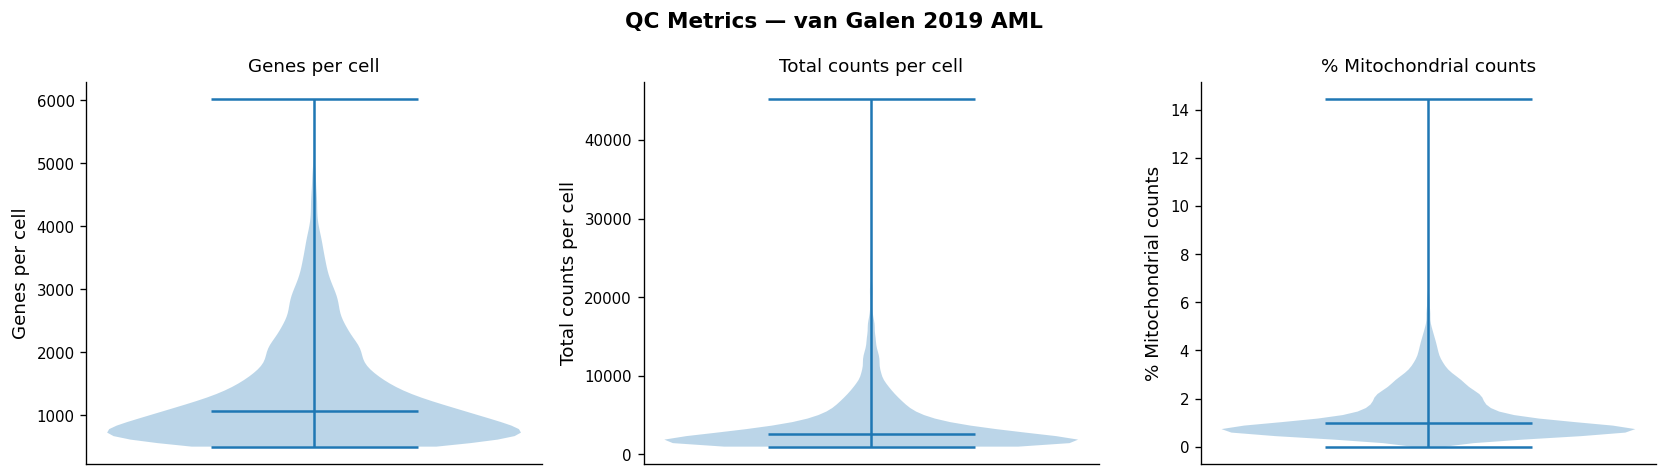

In [6]:
plot_qc_violin(adata, save_path="../figures/01_qc_violin.png")

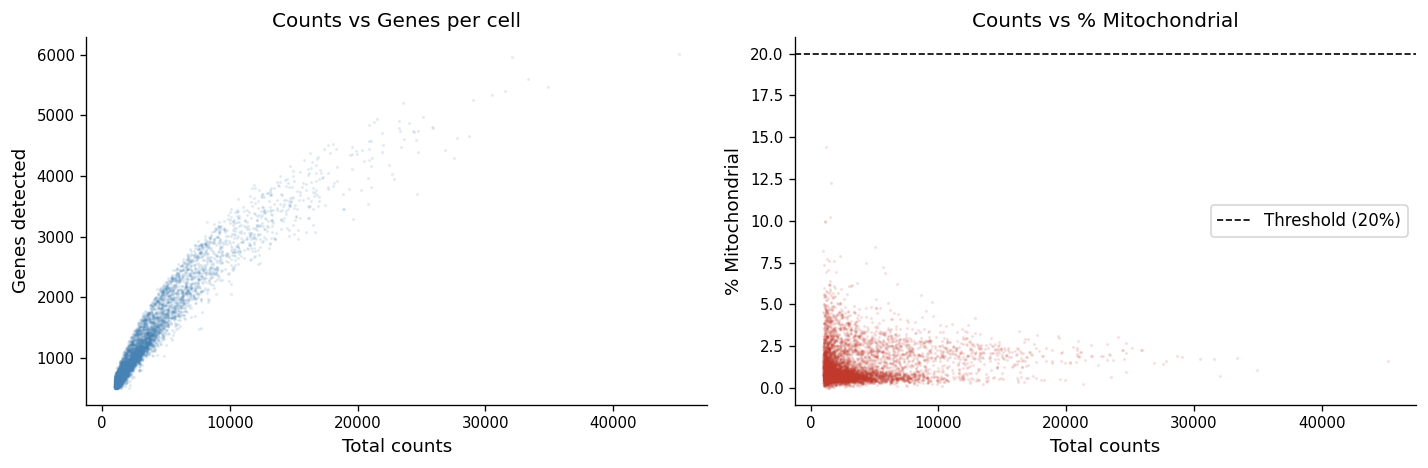

In [7]:
# Scatter: total_counts vs n_genes — helps spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    adata.obs['total_counts'], adata.obs['n_genes_by_counts'],
    alpha=0.1, s=1, c='steelblue'
)
axes[0].set_xlabel('Total counts')
axes[0].set_ylabel('Genes detected')
axes[0].set_title('Counts vs Genes per cell')

axes[1].scatter(
    adata.obs['total_counts'], adata.obs['pct_counts_mt'],
    alpha=0.1, s=1, c='#c0392b'
)
axes[1].set_xlabel('Total counts')
axes[1].set_ylabel('% Mitochondrial')
axes[1].set_title('Counts vs % Mitochondrial')
axes[1].axhline(20, color='black', linestyle='--', linewidth=1, label='Threshold (20%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/01_qc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 — Filter low-quality cells

In [8]:
# Adjust thresholds based on the violin plots above
adata = filter_cells_qc(
    adata,
    min_genes=200,
    max_genes=6000,
    max_pct_mt=20.0
)

print(f"\nFinal dataset: {adata.n_obs} cells × {adata.n_vars} genes")

QC filtering: 5997 → 5996 cells retained (1 removed, 0.0%)

Final dataset: 5996 cells × 17897 genes


In [9]:
# Save filtered object for next notebook
adata.write('../data/raw/adata_01_qc.h5ad')
print("Saved: ../data/raw/adata_01_qc.h5ad")

Saved: ../data/raw/adata_01_qc.h5ad


## Summary

| Step | Cells |
|------|-------|
| Before QC | (see above) |
| After QC | (see above) |

**Next:** Notebook 02 — Normalization, HVG selection, PCA, Harmony batch correction.